# Project Spaceship Titanic



# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
# Affichage plus lisible dans le notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

# Style des graphiques
sns.set_theme()

In [3]:
# Chemins relatifs 
DATA_DIR = "data"

TRAIN_PATH = f"{DATA_DIR}/train.csv"
TEST_PATH = f"{DATA_DIR}/test.csv"
SAMPLE_SUB_PATH = f"{DATA_DIR}/sample_submission.csv"

# Chargement
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

train.shape, test.shape

((8693, 14), (4277, 13))

### 1. Exploration 

In [5]:
print("Train head:")
display(train.head())

print("\nTest head:")
display(test.head())

print("\nInfos train:")
print(train.info())

print("\nInfos test:")
print(test.info())


Train head:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True



Test head:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez



Infos train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Infos test:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 # 

In [6]:
# Statistiques descriptives - variables numériques
print("Description des variables numériques (train) :")
display(train.describe())

# Statistiques descriptives - variables catégorielles / booléennes
print("\nDescription des variables catégorielles (train) :")
display(train.describe(include=["object", "bool"]))

# Nombre de modalités par colonne catégorielle
print("\nNombre de modalités uniques par colonne catégorielle :")
display(train.select_dtypes(include=["object", "bool"]).nunique())

# Valeurs manquantes brutes
print("\nValeurs manquantes (train) :")
display(train.isna().sum())


Description des variables numériques (train) :


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000,8512.000,8510.000,8485.000,8510.000,8505.000
mean,28.828,224.688,458.077,173.729,311.139,304.855
std,14.489,666.718,1611.489,604.696,1136.706,1145.717
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,19.000,0.000,0.000,0.000,0.000,0.000
50%,27.000,0.000,0.000,0.000,0.000,0.000
75%,38.000,47.000,76.000,27.000,59.000,46.000
max,79.000,14327.000,29813.000,23492.000,22408.000,24133.000



Description des variables catégorielles (train) :


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name,Transported
count,8693,8492,8476,8494,8511,8490,8493,8693
unique,8693,3,2,6560,3,2,8473,2
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Anton Woody,True
freq,1,4602,5439,8,5915,8291,2,4378



Nombre de modalités uniques par colonne catégorielle :


PassengerId    8693
HomePlanet        3
CryoSleep         2
Cabin          6560
Destination       3
VIP               2
Name           8473
Transported       2
dtype: int64


Valeurs manquantes (train) :


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
print("\nDistribution de la cible Transported :")
print(train["Transported"].value_counts())
print("\nDistribution relative :")
print(train["Transported"].value_counts(normalize=True))



Distribution de la cible Transported :
Transported
True     4378
False    4315
Name: count, dtype: int64

Distribution relative :
Transported
True     0.504
False    0.496
Name: proportion, dtype: float64


In [8]:
target_col = "Transported"

# On enlève la cible pour analyser les features
features = train.drop(columns=[target_col])

num_cols = features.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = features.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)


Colonnes numériques : ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Colonnes catégorielles : ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [9]:
print("Description des variables numériques :")
display(train[num_cols].describe())

print("\nDescription des variables catégorielles :")
display(train[cat_cols].describe())


Description des variables numériques :


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000,8512.000,8510.000,8485.000,8510.000,8505.000
mean,28.828,224.688,458.077,173.729,311.139,304.855
std,14.489,666.718,1611.489,604.696,1136.706,1145.717
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,19.000,0.000,0.000,0.000,0.000,0.000
50%,27.000,0.000,0.000,0.000,0.000,0.000
75%,38.000,47.000,76.000,27.000,59.000,46.000
max,79.000,14327.000,29813.000,23492.000,22408.000,24133.000



Description des variables catégorielles :


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Anton Woody
freq,1,4602,5439,8,5915,8291,2


<Figure size 2000x1400 with 0 Axes>

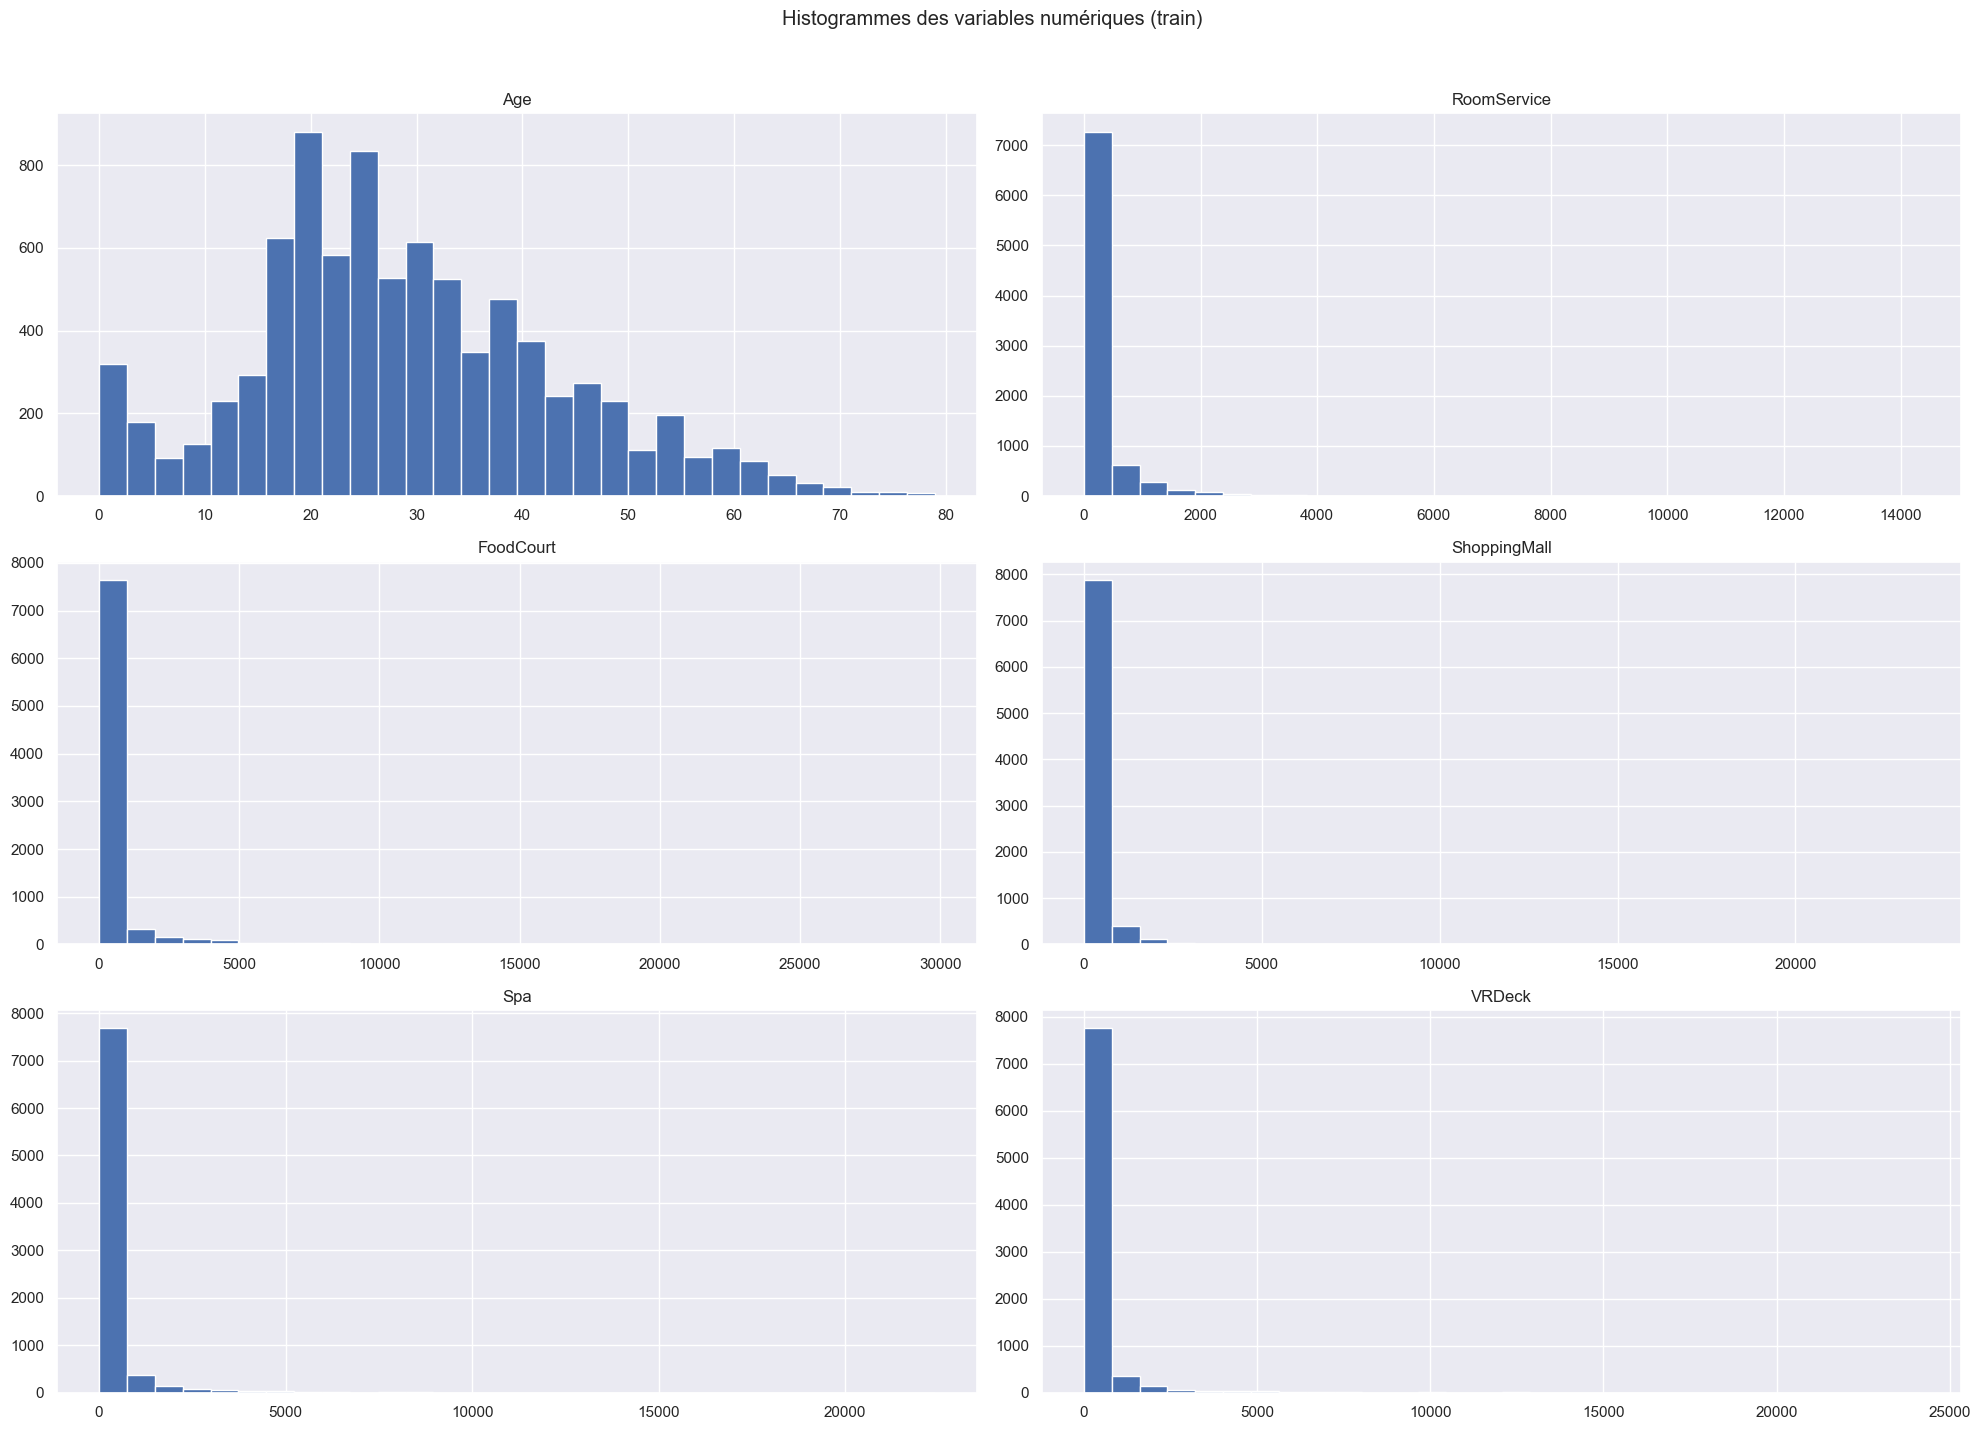

In [13]:
plt.figure(figsize=(20, 14))
train[num_cols].hist(figsize=(20, 14), bins=30)
plt.suptitle("Histogrammes des variables numériques (train)", y=1.02)
plt.tight_layout()
plt.show()


In [14]:
crosstab_hp = pd.crosstab(
    index=train["HomePlanet"],
    columns=train["Transported"],
    normalize="index"  # pour voir des proportions par planète
)

print("Proportion de passagers transportés par HomePlanet :")
display(crosstab_hp)


Proportion de passagers transportés par HomePlanet :


Transported,False,True
HomePlanet,,
Earth,0.576,0.424
Europa,0.341,0.659
Mars,0.477,0.523


Valeurs manquantes dans train (%):


CryoSleep       2.496
ShoppingMall    2.393
VIP             2.335
HomePlanet      2.312
Name            2.301
Cabin           2.289
VRDeck          2.163
Spa             2.105
FoodCourt       2.105
Destination     2.094
RoomService     2.082
Age             2.059
PassengerId     0.000
Transported     0.000
dtype: float64


Valeurs manquantes dans test (%):


FoodCourt       2.478
Spa             2.361
Cabin           2.338
ShoppingMall    2.291
Name            2.198
VIP             2.174
CryoSleep       2.174
Destination     2.151
Age             2.128
HomePlanet      2.034
RoomService     1.917
VRDeck          1.870
PassengerId     0.000
dtype: float64

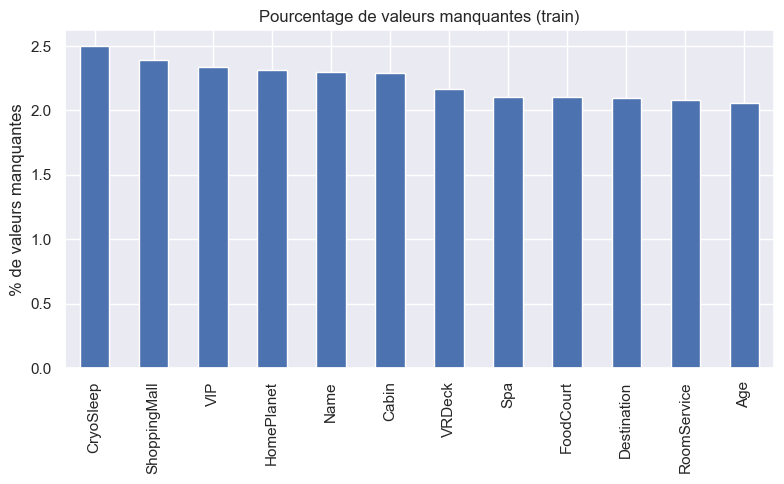

In [10]:
# Pourcentage de valeurs manquantes par colonne (train)
missing_train = train.isna().mean().sort_values(ascending=False) * 100
print("Valeurs manquantes dans train (%):")
display(missing_train)

# Même chose pour test
missing_test = test.isna().mean().sort_values(ascending=False) * 100
print("\nValeurs manquantes dans test (%):")
display(missing_test)

# Petit barplot des colonnes les plus manquantes (optionnel)
plt.figure(figsize=(8, 5))
missing_train[missing_train > 0].plot(kind="bar")
plt.title("Pourcentage de valeurs manquantes (train)")
plt.ylabel("% de valeurs manquantes")
plt.tight_layout()
plt.show()


Distribution de la cible

In [11]:
train[target_col].value_counts(dropna=False)

Transported
True     4378
False    4315
Name: count, dtype: int64

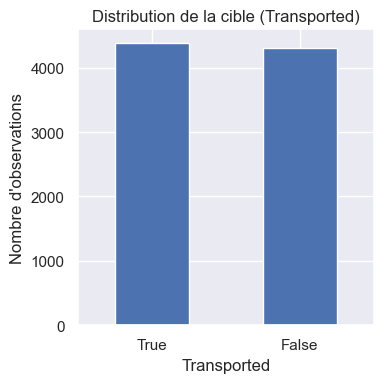

In [12]:
# Avec visualisation
plt.figure(figsize=(4, 4))
train[target_col].value_counts().plot(kind="bar")
plt.title("Distribution de la cible (Transported)")
plt.xticks(rotation=0)
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()


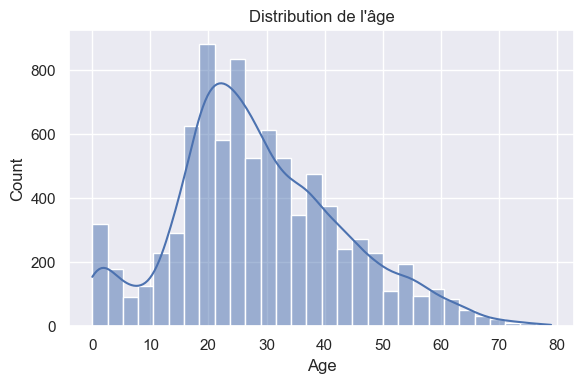

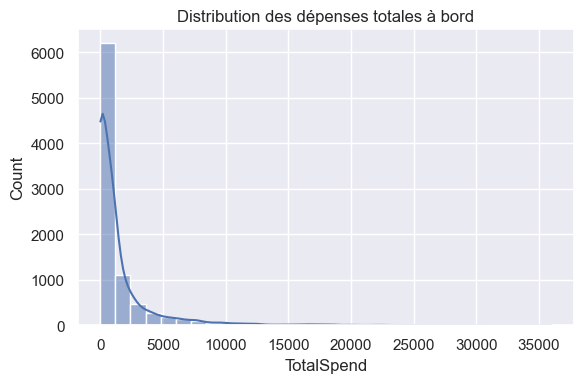

In [17]:
# Exemple : distribution de l'âge
plt.figure(figsize=(6, 4))
sns.histplot(train["Age"], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.tight_layout()
plt.show()

# Exemple : dépenses totales à bord
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train["TotalSpend"] = train[spend_cols].sum(axis=1)

plt.figure(figsize=(6, 4))
sns.histplot(train["TotalSpend"], bins=30, kde=True)
plt.title("Distribution des dépenses totales à bord")
plt.tight_layout()
plt.show()


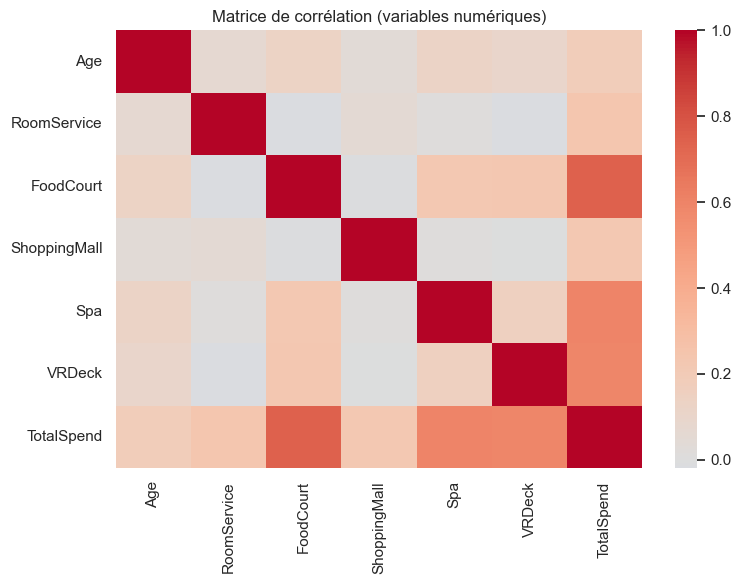

In [18]:
plt.figure(figsize=(8, 6))
corr = train[num_cols + ["TotalSpend"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (variables numériques)")
plt.tight_layout()
plt.show()


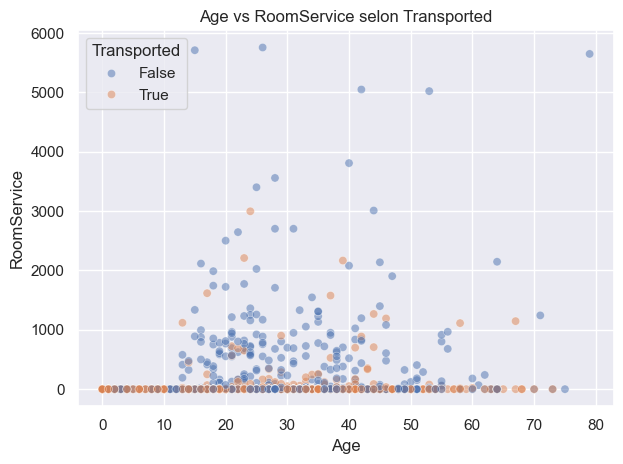

In [16]:
target_col = "Transported"

subset = train[["Age", "RoomService", target_col]].dropna()
subset = subset.sample(n=min(1000, len(subset)), random_state=42)

ax = sns.scatterplot(
    x="Age",
    y="RoomService",
    data=subset,
    hue=target_col,
    alpha=0.5,
)

plt.title("Age vs RoomService selon Transported")
plt.tight_layout()
plt.show()


Nettoyage

Créer une copie de travail